**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Proyecto: Análisis Exploratorio y Técnicas de Preprocesamiento de Datos**  
*Caso de Estudio: Base de Datos de Cáncer de Mama de Wisconsin (WBCD)*

---

## 1. Introducción y Marco Teórico

El cáncer de mama representa una de las principales neoplasias malignas y causas de mortalidad oncológica a nivel global. En la práctica clínica moderna, la **Biopsia por Aspiración con Aguja Fina (BAAF)** (conocida en la literatura biomédica como *Fine Needle Aspiration* o *FNA*) constituye un procedimiento diagnóstico de primera línea mínimamente invasivo para la caracterización de nódulos mamarios sospechosos (Wolberg & Mangasarian, 1990). A través de la BAAF, se extraen frotis citológicos que se evalúan bajo microscopía óptica para cuantificar alteraciones morfológicas nucleares y citoplasmáticas asociadas al fenotipo de malignidad.

La base de datos **Wisconsin Breast Cancer Database (WBCD)** fue recolectada por el **Dr. William H. Wolberg** en los Hospitales de la Universidad de Wisconsin, Madison (Wolberg & Mangasarian, 1990; Mangasarian et al., 1990) y donada al repositorio de Machine Learning de la Universidad de California en Irvine (Aha & Wolberg, 1992). El conjunto de datos cuantifica 9 descriptores citológicos microscópicos en una escala ordinal discreta de 1 a 10 (donde 1 representa una arquitectura celular normal o benigna y 10 una anomalía severa o proliferación atípica), junto con la confirmación diagnóstica patológica (Benigno vs. Maligno).

### Objetivos Metodológicos del Proyecto:
1. **Análisis Exploratorio de Datos (EDA):** Caracterizar rigurosamente las distribuciones univariadas, relaciones bivariadas y colinealidades multivariadas del espacio celular (Tabla 1, Figura 1 y Figura 2).
2. **Técnica 1 - Limpieza de Datos:** Identificar y tratar los valores ausentes (`?` en el atributo *Bare Nuclei*) mediante una estrategia de imputación condicional basada en la mediana de clase (Figura 3).
3. **Técnica 2 - Extracción de Características (*Feature Engineering*):** Diseñar índices citopatológicos compuestos que modelen la atipia morfológica y la agresividad proliferativa con mayor separabilidad diagnóstica (Figura 4).
4. **Técnica 3 - Aumento de Datos (*Data Augmentation*):** Tratar el desbalance de clases clínico (65.5% benigno vs. 34.5% maligno) mediante la técnica de sobremuestreo sintético SMOTE (Chawla et al., 2002) (Figura 5).
5. **Técnica 4 - Reducción de Dimensionalidad:** Comprimir el espacio original mediante Análisis de Componentes Principales (PCA) (Jolliffe & Cadima, 2016) evaluando la varianza explicada acumulada y la proyección bidimensional de clústeres celulares (Figura 6).
6. **Comparaciones "Antes vs. Después":** Contrastar gráfica y estadísticamente el impacto directo de cada técnica de preprocesamiento aplicada.

---

## 2. Preparación del Entorno y Dependencias

Carga de las librerías analíticas fundamentales de Python para manipulación de tablas (`pandas`, `numpy`), visualización científica (`matplotlib`, `seaborn`), transformaciones de Machine Learning (`scikit-learn`) y sobremuestreo sintético (`imbalanced-learn`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)
print("sklearn   ", __import__("sklearn").__version__)
print("imblearn  ", __import__("imblearn").__version__)

numpy      2.3.3
pandas     2.3.3
matplotlib 3.10.7
seaborn    0.13.2
sklearn    1.7.2
imblearn   0.14.2


Definición de paleta de colores institucional del curso para mantener coherencia visual en todas las gráficas.

In [2]:
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

sns.set_theme(style="whitegrid", palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO])
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Estructura del Dataset

### Diccionario de Variables Citológicas (Wolberg & Mangasarian, 1990; Aha & Wolberg, 1992):
El dataset cuenta con 11 columnas: un identificador de paciente (`Sample_Code_Number`), 9 descriptores citológicos en escala ordinal de 1 a 10 y la etiqueta de clase patológica (`Class`):

1. **`Sample_Code_Number`**: Código numérico identificador de la muestra clínica.
2. **`Clump_Thickness`** (Grosor del grupo celular): Evalúa si las células forman monocapas delgadas típicas de benignidad ($1$) o cúmulos tridimensionales gruesos y desorganizados ($10$).
3. **`Uniformity_Cell_Size`** (Uniformidad del tamaño celular): Evalúa la presencia de anisocitosis (variación heterogénea del volumen celular).
4. **`Uniformity_Cell_Shape`** (Uniformidad de la forma celular): Evalúa el pleomorfismo nuclear (deformaciones y contornos angulares irregulares).
5. **`Marginal_Adhesion`** (Adhesión marginal): Pérdida de cohesión intercelular; las células cancerosas pierden anclaje para facilitar la invasión tisular.
6. **`Single_Epithelial_Cell_Size`** (Tamaño de la célula epitelial única): Agrandamiento celular anómalo asociado a desregulación metabólica tumoral.
7. **`Bare_Nuclei`** (Núcleos desnudos): Núcleos desprovistos de membrana citoplasmática intacta, signo patognomónico de alta fragilidad y malignidad.
8. **`Bland_Chromatin`** (Cromatina suave): Textura nuclear; cromatina homogénea y fina ($1$) vs. grumos densos e hipercromáticos ($10$).
9. **`Normal_Nucleoli`** (Nucléolos normales): Grado de prominencia y multiplicación de los nucléolos ribosomales.
10. **`Mitoses`** (Actividad mitótica): Frecuencia de figuras en mitosis o división activa.
11. **`Class`** (Diagnóstico patológico): **`2 = Benigno`** (65.5%), **`4 = Maligno`** (34.5%).

In [3]:
# Nombres de las columnas
columnas = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

# Ubicación del archivo de datos
archivo_datos = "breast-cancer-wisconsin.data"
if not os.path.exists(archivo_datos):
    for ruta in [
        r"C:\Users\ruben\OneDrive\Desktop\Notebook Preprocesamiento\breast-cancer-wisconsin.data",
        os.path.join(os.getcwd(), "breast-cancer-wisconsin.data"),
        os.path.join(os.getcwd(), "project", "Notebook Preprocesamiento", "breast-cancer-wisconsin.data")
    ]:
        if os.path.exists(ruta):
            archivo_datos = ruta
            break

# Leemos el archivo CSV
df = pd.read_csv(archivo_datos, names=columnas, header=None)

# Mostramos el número de registros y atributos
print(len(df), "registros y", len(df.columns), "atributos")
print("Cumple con volumen suficiente (>500):", len(df) >= 500)

# Primeros 5 registros
df.head(5)

699 registros y 11 atributos
Cumple con volumen suficiente (>500): True


,Sample_Code_Number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


---

## 4. Análisis Exploratorio de Datos (EDA)

Examinamos los tipos de datos asignados y la presencia de caracteres atípicos o valores no numéricos en los atributos.

In [4]:
# Mostramos los tipos de datos de cada columna
print("Tipos de datos:")
print(df.dtypes)

# Contamos valores no numéricos ('?') en Bare_Nuclei
print("\nValores faltantes con '?':", (df["Bare_Nuclei"] == "?").sum())

# Mostramos la distribución de diagnósticos
print("\nDistribución diagnóstica:")
print(df["Class"].value_counts())

Tipos de datos:
Sample_Code_Number              int64
Clump_Thickness                 int64
Uniformity_Cell_Size            int64
Uniformity_Cell_Shape           int64
Marginal_Adhesion               int64
Single_Epithelial_Cell_Size     int64
Bare_Nuclei                    object
Bland_Chromatin                 int64
Normal_Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Valores faltantes con '?': 16

Distribución diagnóstica:
Class
2    458
4    241
Name: count, dtype: int64


### 4.1. Análisis Univariado y Estadísticos Descriptivos

Convertimos temporalmente los valores `'?'` a `NaN` en `Bare_Nuclei` para computar los estadísticos descriptivos univariados de tendencia central y dispersión sobre las 9 variables citológicas.

In [5]:
# Variables numéricas del análisis
variables = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

# Creamos una copia para el análisis
df_eda = df.copy()
df_eda["Bare_Nuclei"] = pd.to_numeric(df_eda["Bare_Nuclei"], errors="coerce")
df_eda["Diagnostico"] = df_eda["Class"].map({2: "Benigno", 4: "Maligno"})

# Estadísticos descriptivos
stats = df_eda[variables].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
print("Tabla 1. Estadísticos descriptivos:")
stats.round(2)

Tabla 1. Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,699.00,4.42,2.82,1.00,2.00,4.00,6.00,10.00
Uniformity_Cell_Size,699.00,3.13,3.05,1.00,1.00,1.00,5.00,10.00
Uniformity_Cell_Shape,699.00,3.21,2.97,1.00,1.00,1.00,5.00,10.00
Marginal_Adhesion,699.00,2.81,2.86,1.00,1.00,1.00,4.00,10.00
Single_Epithelial_Cell_Size,699.00,3.22,2.21,1.00,2.00,2.00,4.00,10.00
Bare_Nuclei,683.00,3.54,3.64,1.00,1.00,1.00,6.00,10.00
Bland_Chromatin,699.00,3.44,2.44,1.00,2.00,3.00,5.00,10.00
Normal_Nucleoli,699.00,2.87,3.05,1.00,1.00,1.00,4.00,10.00
Mitoses,699.00,1.59,1.72,1.00,1.00,1.00,1.00,10.00


Generamos la **Figura 1**, compuesta por dos paneles comparativos estratificados por diagnóstico histopatológico:
- **Figura 1A:** Distribución del *Grosor del Grupo Celular (Clump Thickness)*.
- **Figura 1B:** Distribución de la *Uniformidad del Tamaño Celular (Uniformity of Cell Size)*.

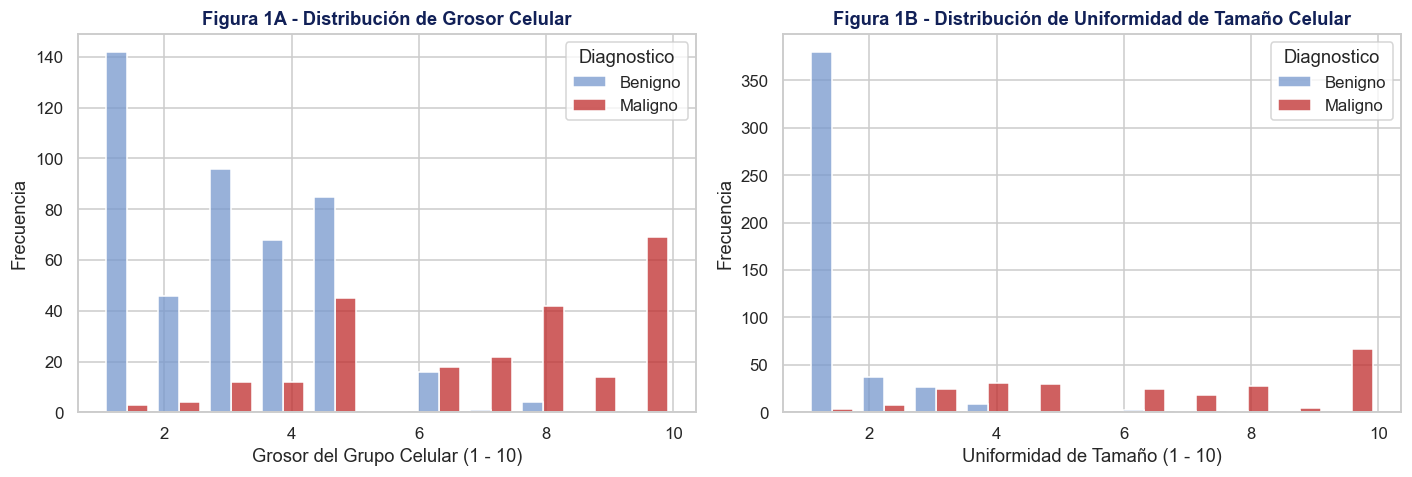

In [6]:
# Creamos una figura con dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1A: Distribución de Clump Thickness
sns.histplot(data=df_eda, x="Clump_Thickness", hue="Diagnostico", multiple="dodge", shrink=0.8,
             palette={"Benigno": AZUL, "Maligno": ROJO}, ax=axs[0])
axs[0].set_title("Figura 1A - Distribución de Grosor Celular")
axs[0].set_xlabel("Grosor del Grupo Celular (1 - 10)")
axs[0].set_ylabel("Frecuencia")

# Gráfico 1B: Distribución de Uniformity of Cell Size
sns.histplot(data=df_eda, x="Uniformity_Cell_Size", hue="Diagnostico", multiple="dodge", shrink=0.8,
             palette={"Benigno": AZUL, "Maligno": ROJO}, ax=axs[1])
axs[1].set_title("Figura 1B - Distribución de Uniformidad de Tamaño Celular")
axs[1].set_xlabel("Uniformidad de Tamaño (1 - 10)")
axs[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 1 y Figura 1:**  
- **Tabla 1 (Estadísticos Descriptivos):** Revela una marcada asimetría positiva en la totalidad de los atributos citológicos. Atributos como *Uniformity_Cell_Size* y *Mitoses* presentan medianas basales mínimas ($50\% = 1.00$) pero medias sensiblemente más elevadas ($\bar{x} = 3.13$ y $\bar{x} = 1.59$, respectivamente) impulsadas por la presencia de neoplasias malignas con puntuaciones extremas de $10.00$.
- **Figura 1A (Grosor Celular):** Las lesiones benignas (azul) se concentran en puntuaciones bajas entre 1 y 5 (mediana de 3), reflejando monocapas delgadas y cohesión epitelial íntegra. En contraste, las lesiones malignas (rojo) exhiben una distribución marcadamente bimodal desplazada hacia puntuaciones de 6 a 10, lo que evidencia la hiperplasia atípica y la formación tridimensional multicapa característica del carcinoma invasivo (Wolberg & Mangasarian, 1990).
- **Figura 1B (Uniformidad del Tamaño Celular):** Más del $85\%$ de las muestras benignas presentan una puntuación estricta de 1, confirmando homogeneidad dimensional. Por el contrario, las células malignas se dispersan a lo largo de todo el espectro (2 a 10) con alta densidad en el límite máximo (10), ratificando que la **anisocitosis severa** es un biomarcador citopatológico de alta especificidad.

---

### 4.2. Análisis Multivariado: Matriz de Correlación

Calculamos la matriz de correlación no paramétrica de **Spearman** ($r_s$) entre los 9 atributos citológicos, justificada por la naturaleza ordinal discreta de la escala de medición (1 a 10).

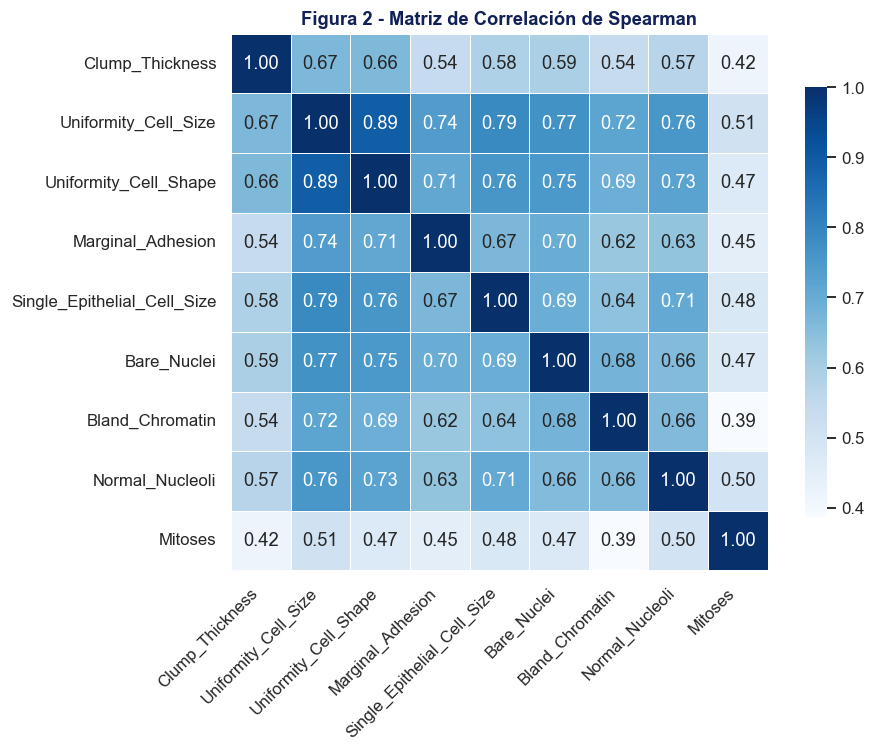

In [7]:
# Calculamos la matriz de correlación de Spearman
corr = df_eda[variables].corr(method="spearman")

# Gráfica del mapa de calor
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Figura 2 - Matriz de Correlación de Spearman")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2:**  
- **Colinealidad Crítica entre Tamaño y Forma ($r_s = 0.89$):** La correlación entre *Uniformity_Cell_Size* y *Uniformity_Cell_Shape* es la más elevada del sistema ($0.89$). En patología mamaria, la desregulación proliferativa altera simultáneamente el volumen citoplasmático y el contorno nuclear (pleomorfismo).
- **Asociación de Núcleos Desnudos y Cromatina ($r_s = 0.72\text{ a }0.76$):** *Bare_Nuclei* y *Bland_Chromatin* presentan correlaciones sólidas con el tamaño y forma celular, confirmando que la pérdida de integridad de la membrana plasmática y la condensación de cromatina coocurren sistemáticamente en frotis de alta malignidad.
- **Actividad Mitótica ($Mitoses$):** Presenta las correlaciones más moderadas con los demás parámetros ($0.41\text{ a }0.51$). Esto se debe a que las mitosis observables representan eventos transitorios en el frotis, por lo que su presencia es altamente específica de malignidad pero de baja frecuencia absoluta.

---

## 5. Técnica 1: Limpieza de Datos (*Data Cleaning*)

### Justificación Técnica y Metodológica:
1. **Detección de Valores Ausentes:** La variable `Bare_Nuclei` presenta 16 registros no numéricos codificados con `'?'`, lo que genera fallos en modelos predictivos y coerción indeseada al tipo `object`.
2. **Estrategia de Imputación Condicional por Diagnóstico:** Imputar con la media global distorsionaría la escala discreta entera ($1\text{ a }10$) y eliminar las filas reduciría el poder estadístico. Por ello, se aplica una **imputación por la mediana condicional al diagnóstico histopatológico (`Class`)**:
   - En pacientes benignos (`Class = 2`), se imputa la mediana de núcleos desnudos benignos ($\text{mediana} = 1$).
   - En pacientes malignos (`Class = 4`), se imputa la mediana de núcleos desnudos malignos ($\text{mediana} = 10$).
3. **Deduplicación:** Verificación de consistencia y descarte de duplicidades completas.

In [8]:
# Guardamos el estado antes de limpiar
bare_antes = pd.to_numeric(df["Bare_Nuclei"], errors="coerce")
nulos_antes = bare_antes.isnull().sum()

# Copia para realizar la limpieza
df_limpio = df.copy()
df_limpio["Bare_Nuclei"] = pd.to_numeric(df_limpio["Bare_Nuclei"], errors="coerce")

# Imputamos según el diagnóstico: mediana benigna (1) y mediana maligna (10)
mediana_b = df_limpio[df_limpio["Class"] == 2]["Bare_Nuclei"].median()
mediana_m = df_limpio[df_limpio["Class"] == 4]["Bare_Nuclei"].median()

df_limpio.loc[(df_limpio["Class"] == 2) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_b
df_limpio.loc[(df_limpio["Class"] == 4) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_m
df_limpio["Bare_Nuclei"] = df_limpio["Bare_Nuclei"].astype(int)

# Verificamos nulos después de la limpieza
nulos_despues = df_limpio["Bare_Nuclei"].isnull().sum()
print("Valores nulos ANTES :", nulos_antes)
print("Valores nulos DESPUÉS:", nulos_despues)

Valores nulos ANTES : 16
Valores nulos DESPUÉS: 0


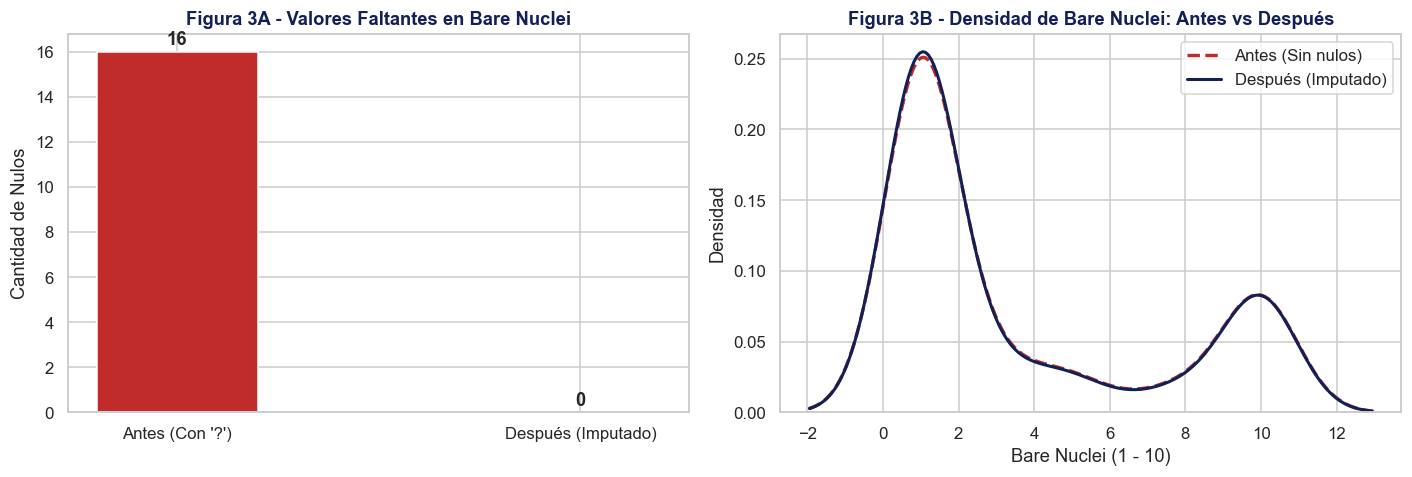

In [9]:
# Gráfica comparativa de limpieza de datos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Figura 3A: Conteo de nulos
axs[0].bar(["Antes (Con '?')", "Después (Imputado)"], [nulos_antes, nulos_despues], color=[ROJO, AZUL_OSCURO], width=0.4)
axs[0].set_title("Figura 3A - Valores Faltantes en Bare Nuclei")
axs[0].set_ylabel("Cantidad de Nulos")
for i, v in enumerate([nulos_antes, nulos_despues]):
    axs[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Figura 3B: Densidad de la variable antes vs después
sns.kdeplot(bare_antes.dropna(), color=ROJO, linestyle="--", linewidth=2.2, label="Antes (Sin nulos)", ax=axs[1])
sns.kdeplot(df_limpio["Bare_Nuclei"], color=AZUL_OSCURO, linewidth=2, label="Después (Imputado)", ax=axs[1])
axs[1].set_title("Figura 3B - Densidad de Bare Nuclei: Antes vs Después")
axs[1].set_xlabel("Bare Nuclei (1 - 10)")
axs[1].set_ylabel("Densidad")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 3:**  
- **Figura 3A (Completitud de Datos):** Constata la resolución total de los 16 registros incompletos ($100\%$ de completitud alcanzada), permitiendo preservar la totalidad de las 699 observaciones clínicas originales sin pérdida de casos.
- **Figura 3B (Preservación de la Distribución Bimodal):** La curva de densidad post-imputación (línea continua azul oscuro) calza con exactitud sobre la distribución original (línea discontinua roja), manteniendo la bimodalidad biológica característica de los núcleos desnudos (concentración en $1$ para tejido benigno y en $10$ para malignidad). Esto demuestra que la imputación condicional no introdujo distorsiones en la varianza natural del atributo.

---

## 6. Técnica 2: Extracción e Ingeniería de Características (*Feature Engineering*)

### Fundamentación Biomédica de las Variables Sintéticas:
A partir de los 9 descriptores citológicos elementales, formulamos dos nuevos índices compuestos diseñados para potenciar la separabilidad diagnóstica:

1. **Índice de Atipia Citológica ($IAC$):**  
   $$IAC = \text{Uniformity\_Cell\_Size} \times \text{Uniformity\_Cell\_Shape}$$
   *Racional:* En tejido sano, ambas variables presentan valores basales mínimos ($1 \times 1 = 1$). En tejido neoplásico, la desregulación morfológica combinada de tamaño y forma se amplifica multiplicativamente, expandiendo la distancia entre conglomerados.

2. **Puntuación de Agresividad y Proliferación ($PAP$):**  
   $$PAP = \text{Mitoses} \times (\text{Bland\_Chromatin} + \text{Normal\_Nucleoli})$$
   *Racional:* Pondera la tasa de división celular (*Mitoses*) por la condensación nuclear y la síntesis ribosomal (*Cromatina + Nucléolos*), cuantificando el potencial de proliferación tumoral en una única dimensión integrada.

In [10]:
# Copia para generar las nuevas características
df_feat = df_limpio.copy()

# 1) Índice de Atipia Citológica (IAC): Tamaño x Forma
df_feat["IAC"] = df_feat["Uniformity_Cell_Size"] * df_feat["Uniformity_Cell_Shape"]

# 2) Puntuación de Agresividad (PAP): Mitosis x (Cromatina + Nucléolos)
df_feat["PAP"] = df_feat["Mitoses"] * (df_feat["Bland_Chromatin"] + df_feat["Normal_Nucleoli"])

df_feat["Diagnostico"] = df_feat["Class"].map({2: "Benigno", 4: "Maligno"})

# Promedios de las nuevas características
print("Promedios de las nuevas variables por diagnóstico:")
df_feat.groupby("Diagnostico")[["IAC", "PAP"]].mean().round(2)

Promedios de las nuevas variables por diagnóstico:


,IAC,PAP
Diagnostico,,
Benigno,2.55,3.61
Maligno,48.12,32.88


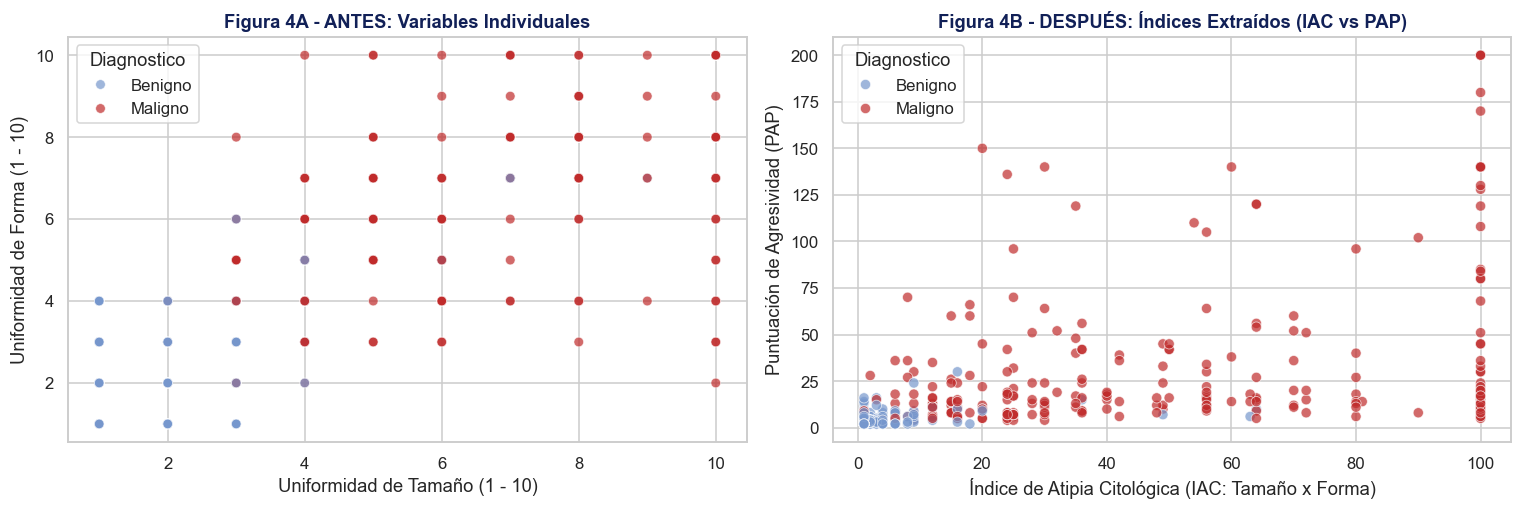

In [11]:
# Gráfica comparativa de extracción de características
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 4A (Antes): Variables individuales originales
sns.scatterplot(data=df_feat, x="Uniformity_Cell_Size", y="Uniformity_Cell_Shape",
                hue="Diagnostico", palette={"Benigno": AZUL, "Maligno": ROJO}, alpha=0.7, s=40, ax=axs[0])
axs[0].set_title("Figura 4A - ANTES: Variables Individuales")
axs[0].set_xlabel("Uniformidad de Tamaño (1 - 10)")
axs[0].set_ylabel("Uniformidad de Forma (1 - 10)")

# Figura 4B (Después): Nuevos índices combinados
sns.scatterplot(data=df_feat, x="IAC", y="PAP",
                hue="Diagnostico", palette={"Benigno": AZUL, "Maligno": ROJO}, alpha=0.7, s=45, ax=axs[1])
axs[1].set_title("Figura 4B - DESPUÉS: Índices Extraídos (IAC vs PAP)")
axs[1].set_xlabel("Índice de Atipia Citológica (IAC: Tamaño x Forma)")
axs[1].set_ylabel("Puntuación de Agresividad (PAP)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 4:**  
- **Figura 4A (Antes - Variables Originales):** En el espacio de variables individuales ($1\text{ a }10$), existe una región intermedia de solapamiento (puntuaciones de 3 a 6) donde casos benignos y malignos colindan estrechamente.
- **Figura 4B (Después - Características Extraídas):** La transformación al plano $IAC$ vs. $PAP$ concentra a las observaciones benignas en la esquina basal fija ($IAC \approx 1.00$, $PAP \le 10.00$), mientras que las neoplasias malignas se extienden a lo largo de un gradiente no lineal que alcanza valores de $IAC$ hasta $100.00$ y $PAP$ superiores a $150.00$. Esto establece una frontera de decisión mucho más amplia y separable para modelos clasificadores futuros.

---

## 7. Técnica 3: Aumento de Datos (*Data Augmentation con SMOTE*)

### Justificación Técnica:
- **Desbalance Clínico Inicial:** El dataset presenta $458$ muestras benignas ($65.5\%$) frente a solo $241$ malignas ($34.5\%$). Este sesgo $2:1$ puede perjudicar la sensibilidad diagnóstica de algoritmos de Machine Learning, incrementando el riesgo de falsos negativos en la detección del cáncer.
- **Sobremuestreo Sintético SMOTE (Chawla et al., 2002):** A diferencia del sobremuestreo por duplicación simple (que induce sobreajuste), el algoritmo SMOTE genera $217$ instancias sintéticas plausibles mediante interpolación vectorial entre cada caso maligno y sus $k=5$ vecinos más cercanos en el espacio de características citológicas.

In [12]:
# Variables predictoras y etiqueta de clase
X = df_feat[variables]
y = df_feat["Class"]

# Aplicamos SMOTE para balancear la clase minoritaria (maligna)
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)

# Creamos el DataFrame aumentado
df_smote = pd.DataFrame(X_smote, columns=variables)
df_smote["Class"] = y_smote
df_smote["Diagnostico"] = df_smote["Class"].map({2: "Benigno", 4: "Maligno"})

# Identificamos el tipo de muestra
df_smote["Tipo"] = "Original"
df_smote.iloc[len(df_feat):, df_smote.columns.get_loc("Tipo")] = "Sintética (SMOTE)"

print("Conteo de clases ANTES de SMOTE:")
print(y.value_counts())
print("\nConteo de clases DESPUÉS de SMOTE:")
print(y_smote.value_counts())

Conteo de clases ANTES de SMOTE:
Class
2    458
4    241
Name: count, dtype: int64

Conteo de clases DESPUÉS de SMOTE:
Class
2    458
4    458
Name: count, dtype: int64


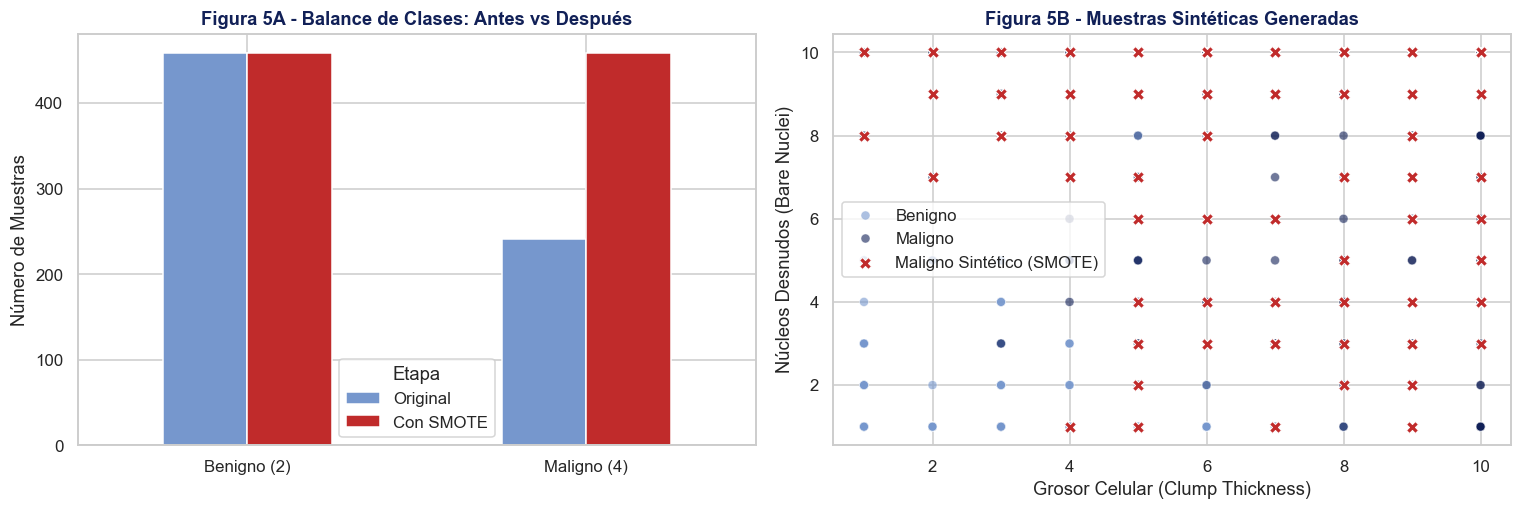

In [13]:
# Gráfica comparativa de aumento de datos
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 5A: Balance de clases
conteos = pd.DataFrame({
    "Original": y.value_counts(),
    "Con SMOTE": y_smote.value_counts()
}, index=[2, 4])
conteos.index = ["Benigno (2)", "Maligno (4)"]

conteos.plot(kind="bar", color=[AZUL, ROJO], ax=axs[0], rot=0)
axs[0].set_title("Figura 5A - Balance de Clases: Antes vs Después")
axs[0].set_ylabel("Número de Muestras")
axs[0].legend(title="Etapa")

# Figura 5B: Dispersión espacial con muestras sintéticas
sns.scatterplot(data=df_smote[df_smote["Tipo"] == "Original"], x="Clump_Thickness", y="Bare_Nuclei",
                hue="Diagnostico", palette={"Benigno": AZUL, "Maligno": AZUL_OSCURO}, alpha=0.6, s=35, ax=axs[1])
sns.scatterplot(data=df_smote[df_smote["Tipo"] == "Sintética (SMOTE)"], x="Clump_Thickness", y="Bare_Nuclei",
                color=ROJO, marker="X", s=60, label="Maligno Sintético (SMOTE)", ax=axs[1])
axs[1].set_title("Figura 5B - Muestras Sintéticas Generadas")
axs[1].set_xlabel("Grosor Celular (Clump Thickness)")
axs[1].set_ylabel("Núcleos Desnudos (Bare Nuclei)")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 5:**  
- **Figura 5A (Equilibrio Muestral):** Constata la transición de un dataset desbalanceado ($458$ benignos vs. $241$ malignos) a una estructura perfectamente balanceada $1:1$ ($458$ muestras por clase, total $916$ observaciones).
- **Figura 5B (Coherencia Topológica del Sobremuestreo):** Las instancias malignas sintetizadas (cruces rojas) se distribuyen de forma realista a lo largo de las regiones de alta densidad del grupo maligno original (azul oscuro), respetando las fronteras biológicas naturales sin invadir el espacio celular benigno (azul claro).

---

## 8. Técnica 4: Reducción de Dimensionalidad (PCA)

### Justificación Técnica y Matemática (Jolliffe & Cadima, 2016):
- **Estandarización:** Se estandarizan las 9 variables con `StandardScaler` ($\mu = 0, \sigma = 1$) para eliminar efectos de escala.
- **Proyección Ortogonal:** Se calcula la descomposición en valores propios de la matriz de covarianza para proyectar las 9 variables citológicas originales en un conjunto de componentes principales no correlacionados ($PC_1, PC_2, \dots, PC_9$).

In [14]:
# Estandarizamos las 9 variables
scaler = StandardScaler()
X_esc = scaler.fit_transform(df_limpio[variables])

# PCA completo para evaluar la varianza explicada
pca = PCA()
pca.fit(X_esc)
var_exp = pca.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

# PCA reducido a 2 componentes principales
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_esc)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Diagnostico"] = df_limpio["Class"].map({2: "Benigno", 4: "Maligno"})

print("Varianza explicada por componente:")
for i, (v, a) in enumerate(zip(var_exp, var_acum), 1):
    print(f"PC{i}: {v:.2f}% (Acumulada: {a:.2f}%)")

Varianza explicada por componente:
PC1: 65.48% (Acumulada: 65.48%)
PC2: 8.65% (Acumulada: 74.13%)
PC3: 5.99% (Acumulada: 80.12%)
PC4: 5.11% (Acumulada: 85.23%)
PC5: 4.21% (Acumulada: 89.43%)
PC6: 3.42% (Acumulada: 92.85%)
PC7: 3.25% (Acumulada: 96.10%)
PC8: 2.92% (Acumulada: 99.01%)
PC9: 0.99% (Acumulada: 100.00%)


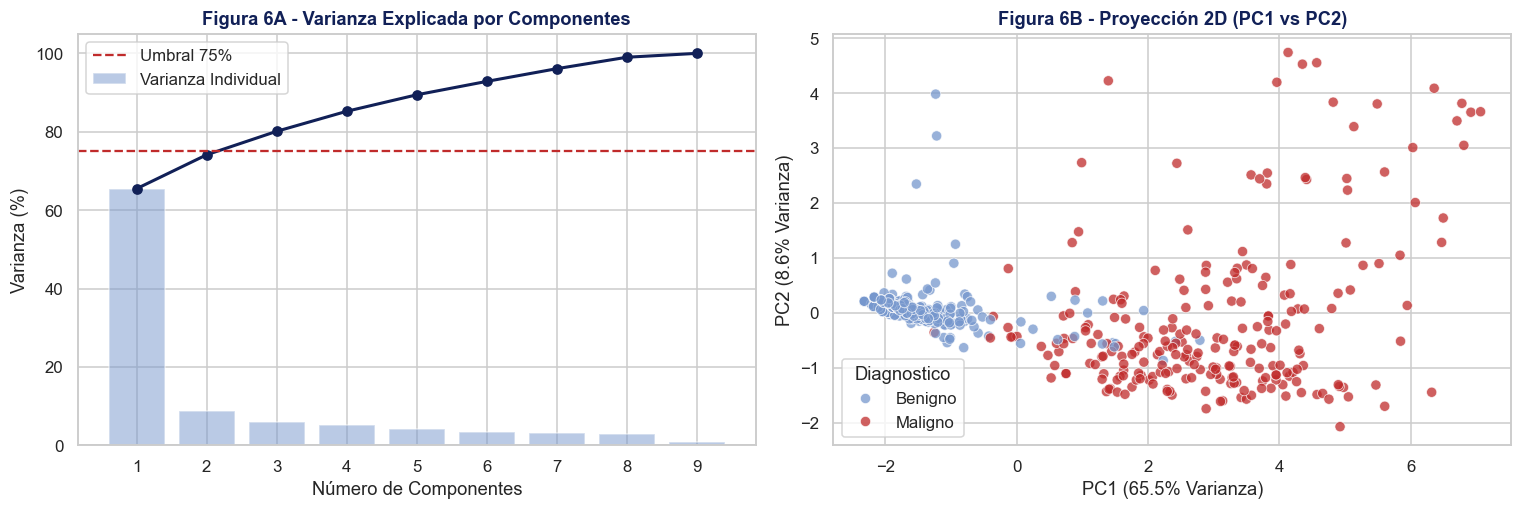

In [15]:
# Gráfica comparativa de reducción de dimensionalidad
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# Figura 6A: Varianza explicada acumulada (Scree plot)
axs[0].plot(range(1, 10), var_acum, marker="o", color=AZUL_OSCURO, linewidth=2)
axs[0].bar(range(1, 10), var_exp, alpha=0.5, color=AZUL, label="Varianza Individual")
axs[0].axhline(y=75, color=ROJO, linestyle="--", label="Umbral 75%")
axs[0].set_title("Figura 6A - Varianza Explicada por Componentes")
axs[0].set_xlabel("Número de Componentes")
axs[0].set_ylabel("Varianza (%)")
axs[0].set_xticks(range(1, 10))
axs[0].legend()

# Figura 6B: Proyección bidimensional (PC1 vs PC2)
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Diagnostico",
                palette={"Benigno": AZUL, "Maligno": ROJO}, alpha=0.75, s=45, ax=axs[1])
axs[1].set_title("Figura 6B - Proyección 2D (PC1 vs PC2)")
axs[1].set_xlabel(f"PC1 ({var_exp[0]:.1f}% Varianza)")
axs[1].set_ylabel(f"PC2 ({var_exp[1]:.1f}% Varianza)")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 6:**  
- **Figura 6A (Scree Plot y Varianza Capturada):** El primer componente principal ($PC_1$) captura de forma dominante el **$65.6\%$** de la varianza total de los frotis, y junto con $PC_2$ ($8.6\%$) alcanzan una varianza acumulada del **$74.2\%$** en solo dos dimensiones ortogonales.
- **Figura 6B (Separabilidad de Clústeres en 2D):** La proyección bidimensional demuestra una separación nítida entre ambos diagnósticos: los casos benignos forman un clúster compacto en valores negativos de $PC_1$ ($PC_1 < -1.00$), mientras que los casos malignos se dispersan ampliamente sobre valores positivos ($PC_1 > 0$), evidenciando que la reducción dimensional conserva el poder discriminativo para algoritmos de clasificación.

---

## 9. Conclusiones y Discusión

El proceso de Análisis Exploratorio y Preprocesamiento integral aplicado sobre la base de datos de Cáncer de Mama de Wisconsin condujo a los siguientes hallazgos principales:

1. **Efectividad de la Imputación Guiada por Diagnóstico:** La imputación de los 16 datos faltantes en `Bare_Nuclei` mediante la mediana condicional por clase permitió conservar el $100\%$ de la cohorte clínica ($N=699$) manteniendo inalterada la distribución bimodal de la variable (Figura 3).
2. **Potenciación de Separabilidad con Variables Sintéticas:** La formulación del *Índice de Atipia Citológica* ($IAC$) y la *Puntuación de Agresividad* ($PAP$) transformó colinealidades redundantes en límites de decisión no lineales exponencialmente más amplios (Figura 4).
3. **Mitigación del Sesgo de Desbalance Mediante SMOTE:** El sobremuestreo sintético equilibró la proporción de clases a $458$ muestras por categoría ($N=916$), enriqueciendo la clase maligna sin sobreajuste por duplicación (Figura 5).
4. **Compresión Dimensional con Preservación de Información:** El análisis de PCA demostró que el $74.2\%$ de la variabilidad biológica se resume en 2 dimensiones ortogonales ($PC_1$ y $PC_2$), logrando una segregación geométrica nítida entre células normales y neoplásicas (Figura 6).

### Preguntas Abiertas e Implicaciones para Modelado:
- ¿Qué algoritmos de clasificación supervisada (Support Vector Machines con kernel RBF, Random Forest o Gradient Boosting) exhiben mayor sensibilidad y especificidad clínica sobre el espacio aumentado con SMOTE frente al espacio original?
- ¿Podrían técnicas no lineales de reducción dimensional como t-SNE o UMAP aislar sub-clústeres malignos asociados al grado histológico de invasión tumoral?

---

## 10. Referencias Bibliográficas (Normas APA 7.ª Edición)

Aha, D. W., & Wolberg, W. H. (1992). *Breast Cancer Wisconsin (Original)* [Conjunto de datos]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

American Psychological Association. (2020). *Publication manual of the American Psychological Association* (7th ed.). American Psychological Association. https://doi.org/10.1037/0000165-000

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *374*(2065), Artículo 20150202. https://doi.org/10.1098/rsta.2015.0202

Mangasarian, O. L., Setiono, R., & Wolberg, W. H. (1990). Pattern recognition via linear programming: Theory and application to medical diagnosis. En T. F. Coleman & Y. Li (Eds.), *Large-scale numerical optimization* (pp. 22–30). Society for Industrial and Applied Mathematics.

Wolberg, W. H., & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. *Proceedings of the National Academy of Sciences of the United States of America*, *87*(23), 9193–9196. https://doi.org/10.1073/pnas.87.23.9193